# Hospital Readmission Risk Prediction for Diabetic Patients

## Executive Summary

This project develops a machine learning model to predict the risk of 30-day hospital 
readmission in diabetic patients using clinical and demographic data from 100,000+ 
patient encounters.

**Dataset:** UCI Diabetes 130-US Hospitals dataset (101,766 records, 50 features)

**Approach:**
- Full data cleaning pipeline with leakage-safe preprocessing
- Three models benchmarked: Logistic Regression, Random Forest, and XGBoost
- XGBoost selected based on best recall and ROC-AUC under stratified cross-validation
- Decision threshold calibrated to achieve ≥ 80% recall while maximizing precision

**Key Results:**
- XGBoost cross-validated recall: 53.3% (default threshold)
- After hyperparameter tuning: 63.9% recall (CV)
- After threshold calibration: 83.4% recall on held-out test set
- ROC-AUC: 0.6629

**Clinical Takeaway:**  
The model correctly identifies over 8 in 10 patients at risk of readmission, 
enabling care teams to prioritize interventions for high-risk patients at discharge. 
Prior inpatient visits, discharge disposition, and total healthcare utilization 
are the strongest predictors of readmission risk.
```



## 1. Problem Statement

### Objective
The objective of this project is to develop a machine learning model capable of 
predicting the likelihood of 30-day hospital readmission in diabetic patients 
based on clinical, administrative, and demographic features.

Early identification of high-risk patients enables timely intervention, optimized 
discharge planning, and improved patient outcomes.

### Target Variable
The target variable for this project is:

- `readmitted_binary` (Binary Classification)
    - 0 → Not readmitted within 30 days
    - 1 → Readmitted within 30 days

### Why 30-Day Readmission Matters
Hospital readmission within 30 days is a key quality metric in healthcare systems 
worldwide. It is associated with poor discharge planning, unresolved medical issues, 
and significant financial penalties for hospitals under value-based care programs.

For diabetic patients specifically, readmission rates are disproportionately high 
due to the chronic and complex nature of the disease. Predictive modeling can help 
healthcare providers:
- Identify high-risk patients before discharge
- Prioritize follow-up care and monitoring
- Reduce avoidable readmissions and associated costs

### Evaluation Priority: Why Recall Matters Most
In medical screening, false negatives are particularly dangerous.

A false negative means:
> A patient who will be readmitted is incorrectly predicted as low-risk.

This can result in premature discharge, lack of follow-up, and worsened outcomes.

Therefore, **Recall** is prioritized in this project, as it measures the model's 
ability to correctly identify patients who will truly be readmitted within 30 days.


## 2. Dataset Overview

### Dataset Source
The dataset used in this project is the **UCI Diabetes 130-US Hospitals dataset**, 
collected from 130 US hospitals between 1999 and 2008. It contains clinical records 
for diabetic patients and is widely used in healthcare machine learning research.

### Dataset Structure
The dataset consists of:
- **101,766** patient encounter records (rows)
- **50** features (columns) covering demographics, hospital encounter details, 
  medications, and diagnosis codes
- A multiclass readmission variable converted to a binary target

### Key Feature Categories

**Demographic Features**
- Age (provided as 10-year interval ranges, e.g. `[60-70)`)
- Gender
- Race

**Hospital Encounter Features**
- Admission type (emergency, elective, urgent, etc.)
- Discharge disposition (home, skilled nursing facility, rehab, etc.)
- Admission source (ER, physician referral, transfer, etc.)
- Time in hospital (number of days)

**Clinical & Medication Features**
- Number of lab procedures performed
- Number of medications administered
- Number of diagnoses recorded
- Individual medication indicators for 23 diabetes-related drugs 
  (e.g. metformin, insulin, glipizide, glyburide)
- Whether diabetes medication was changed during the encounter

**Prior Utilization Features**
- Number of outpatient visits in the year before admission
- Number of emergency visits in the year before admission
- Number of inpatient visits in the year before admission

**Engineered Features (created in this project)**
- `total_visits` — sum of all prior healthcare visits
- `high_utilizer` — binary flag for patients with 3 or more prior visits
- `medication_count` — number of active diabetes medications
- `age_group` — clinical risk grouping (Young, Middle-Aged, Senior)

### Feature Interpretation
Each feature represents a measurable clinical or administrative factor available 
at the time of the patient's hospital encounter — before any readmission outcome 
is known. This ensures all features are leakage-safe and clinically meaningful 
for real-world deployment.

In [3]:
# ===============================
# Import Required Libraries
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

### **Data Dictionary (Features Used)**

| Feature Name | Type | Description |
|-------------|------|-------------|
| race | Categorical | Patient’s race (e.g., Caucasian, AfricanAmerican, Hispanic). |
| gender | Categorical | Patient’s gender (Male / Female). |
| age | Categorical | Patient age grouped into 10-year intervals (e.g., `[60-70)`). |
| admission_type_id | Categorical (Encoded) | Indicates type of hospital admission (e.g., emergency, elective). |
| discharge_disposition_id | Categorical (Encoded) | Indicates patient’s discharge outcome (home, rehab, nursing facility, etc.). |
| admission_source_id | Categorical (Encoded) | Source of hospital admission (e.g., ER, physician referral). |
| time_in_hospital | Numeric | Number of days the patient stayed in the hospital. |
| num_lab_procedures | Numeric | Number of lab tests performed during the encounter. |
| num_medications | Numeric | Number of medications administered during the hospital stay. |
| number_outpatient | Numeric | Outpatient visits in the year before this admission. |
| number_emergency | Numeric | Emergency room visits in the year before this admission. |
| number_inpatient | Numeric | Inpatient visits in the year before this admission. |
| total_visits | Numeric (Engineered) | Total prior healthcare visits (outpatient + emergency + inpatient). |
| high_utilizer | Binary (Engineered) | Indicates frequent hospital usage based on total visits. |
| medication_count | Numeric (Engineered) | Aggregated count of prescribed medications. |
| change | Binary | Whether diabetes medication was changed during the encounter. |
| diabetesMed | Binary | Indicates if the patient received diabetes medication. |
| readmitted | Categorical | Readmission status: `<30`, `>30`, or `NO`. |
| readmitted_binary | Binary (Target) | 1 = readmitted within 30 days, 0 = otherwise. |

In [4]:
# ===============================
# 1. Load Dataset
# ===============================

df = pd.read_csv("diabetic_data.csv") 

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
# Dataset Basic Overview

print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())

print("\nData Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

Dataset Shape: (101766, 50)

Column Names:
 ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Data Types:

encounter_id                 int64
patient_nbr                  int64
race                        object
gender             

### Creating Target Variable

The original dataset includes a multiclass variable `readmitted`:

- "NO" → No readmission
- ">30" → Readmitted after 30 days
- "<30" → Readmitted within 30 days

For this project, we convert it into a binary classification problem:

- 1 → Readmitted within 30 days ("<30")
- 0 → Not readmitted within 30 days ("NO" or ">30")

This allows us to focus specifically on early readmission risk, which is critical for hospital quality metrics and patient care optimization.

In [6]:
# ===============================
# Create Binary Target Variable
# ===============================

df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

print("Target variable created successfully.\n")
print(df['readmitted_binary'].value_counts())

Target variable created successfully.

readmitted_binary
0    90409
1    11357
Name: count, dtype: int64


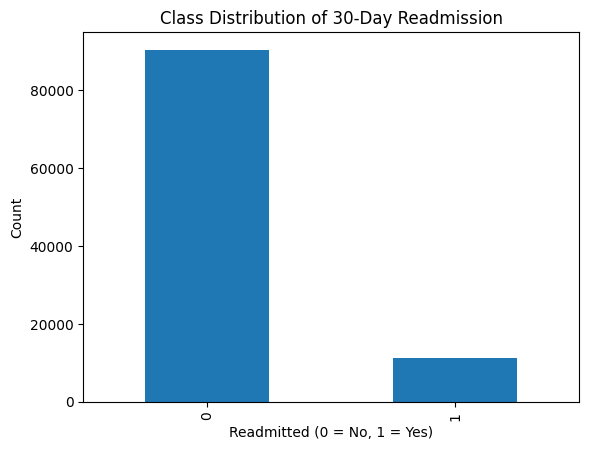


Class Proportions:
readmitted_binary
0    0.888401
1    0.111599
Name: proportion, dtype: float64


In [7]:
# ===============================
# Target Distribution
# ===============================

df['readmitted_binary'].value_counts().plot(kind='bar')
plt.title("Class Distribution of 30-Day Readmission")
plt.xlabel("Readmitted (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

print("\nClass Proportions:")
print(df['readmitted_binary'].value_counts(normalize=True))

### Class Imbalance Analysis

The dataset contains **101,766 patient encounters**, of which only **11,357 (11.2%) 
resulted in a 30-day readmission**. This means for every 1 readmitted patient, 
there are approximately 8 who were not.

This is not a minor statistical inconvenience — it has direct consequences for 
how the model learns, how it is evaluated, and how it should be deployed.

---

### Why Accuracy Is the Wrong Metric Here

A model that predicts "not readmitted" for every single patient would achieve 
**88.8% accuracy** — without learning anything meaningful. In any other context 
that might sound impressive. In a hospital setting, it means **every high-risk 
patient goes home without intervention**.

This is why accuracy is abandoned entirely in this project. The metrics that 
matter are:

- **Recall** — out of all patients who *will* be readmitted, how many did we catch?
- **Precision** — out of all patients we flagged, how many truly were readmitted?
- **ROC-AUC** — how well does the model separate high-risk from low-risk patients 
  across all possible thresholds?

---

### The Real Cost of Getting It Wrong

In healthcare, prediction errors are not symmetric. A missed readmission 
(false negative) and an unnecessary flag (false positive) do not carry equal weight.

| Error Type | What Happens | Clinical Cost |
|------------|-------------|---------------|
| **False Negative** | High-risk patient predicted as safe | Discharged without follow-up → avoidable deterioration, re-hospitalisation under worse conditions, potential patient harm |
| **False Positive** | Low-risk patient flagged as high-risk | Receives extra monitoring or a follow-up call → minor resource cost, no patient harm |

The asymmetry is clear. **Missing a readmission is far more dangerous than 
over-flagging one.** This project is therefore designed to minimise false 
negatives, accepting a higher false positive rate as a deliberate and justified 
tradeoff.

### How Class Imbalance Was Addressed

The 88/12 class split was handled at three levels throughout this project rather 
than relying on a single fix.

**Level 1 — Evaluation Level (Stratified Splitting & Cross-Validation)**  
All train/test splits and cross-validation folds were stratified using `stratify=y` 
and `StratifiedKFold`. This ensures every fold and every evaluation reflects the 
true 88/12 class distribution, preventing the model from being evaluated on an 
accidentally balanced or skewed sample.

**Level 2 — Model Level (Class Weights & scale_pos_weight)**  
Both models used in this project were configured to account for imbalance directly:
- Logistic Regression used `class_weight='balanced'`, which automatically 
  increases the penalty for misclassifying the minority class (readmitted patients)
- XGBoost used `scale_pos_weight=7.86` — computed as the ratio of negative to 
  positive samples — which tells the boosting algorithm that a missed readmission 
  is ~8 times more costly than a missed non-readmission

**Level 3 — Threshold Level (Decision Threshold Calibration)**  
Rather than defaulting to a 0.5 classification threshold, the decision boundary 
was moved to the highest-precision point that still achieves ≥ 80% recall. This 
directly addresses the imbalance problem at prediction time — allowing the model 
to be more sensitive to the minority class without retraining.

**Why Not SMOTE?**  
SMOTE (Synthetic Minority Oversampling Technique) was considered but not applied. 
The combination of class weights and threshold calibration was sufficient to 
achieve 83.4% recall on the test set. SMOTE remains a candidate for future 
iterations, particularly if the model is deployed on datasets with even more 
severe imbalance.

## 3. Data Cleaning

In [8]:
# Handling missing values
df.replace('?', np.nan, inplace=True)

### Handling Missing Values

The dataset uses the symbol `?` to represent missing values.
These were first converted to proper NaN values to allow consistent handling.

Missing values can bias models, especially in healthcare, where absence of information
may correlate with patient severity.

In [9]:
# Dropping highly incomplete columns like weight and some ID columns
df.drop(columns=['weight'], inplace=True)

### Removing Highly Incomplete Features

The `weight` feature contained a large proportion of missing values and was removed
to avoid introducing noise or bias through aggressive imputation.

In [10]:
irrelevant_cols = ['encounter_id', 'patient_nbr']
df.drop(columns=irrelevant_cols, inplace=True)

### Removing Non-Predictive Identifier Columns

Unique identifiers such as encounter and patient IDs were removed since they
do not carry predictive information and may introduce data leakage.

In [11]:
df_clean = df.copy()
df_clean.dropna(subset=['diag_1', 'diag_2', 'diag_3'], inplace=True)

In [12]:
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65,
    '[70-80)': 75, '[80-90)': 85, '[90-100)': 95
}

df_clean['age_midpoint'] = df_clean['age'].map(age_map)

In [13]:
df_clean.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 100244 entries, 1 to 101765
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      98053 non-null   object
 1   gender                    100244 non-null  object
 2   age                       100244 non-null  object
 3   admission_type_id         100244 non-null  int64 
 4   discharge_disposition_id  100244 non-null  int64 
 5   admission_source_id       100244 non-null  int64 
 6   time_in_hospital          100244 non-null  int64 
 7   payer_code                60789 non-null   object
 8   medical_specialty         50762 non-null   object
 9   num_lab_procedures        100244 non-null  int64 
 10  num_procedures            100244 non-null  int64 
 11  num_medications           100244 non-null  int64 
 12  number_outpatient         100244 non-null  int64 
 13  number_emergency          100244 non-null  int64 
 14  number_in

race                         2273
gender                          0
age                             0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide                       0
tolbutamide   

In [14]:
df_clean.drop(columns=['max_glu_serum', 'A1Cresult'], inplace=True)

In [15]:
df_clean.dropna(
    subset=['race', 'diag_1', 'diag_2', 'diag_3'],
    inplace=True
)

In [16]:
df_clean['payer_code'].fillna('Unknown', inplace=True)
df_clean['medical_specialty'].fillna('Unknown', inplace=True)

In [17]:
df_clean.isna().sum()
df_clean.shape

(98053, 47)

### Final Data Cleaning Summary

- Removed highly sparse laboratory features (>80% missing)
- Dropped rows with missing diagnosis codes and race
- Imputed structural categorical missingness using an "Unknown" category
- Maintained separation between raw and cleaned datasets

At this stage, the dataset is fully cleaned and suitable for exploratory analysis
and model training.

### Preventing Data Leakage

Healthcare datasets often include variables that reflect outcomes or post-treatment
decisions. Including such features without review can result in overly optimistic
model performance.

Before exploratory analysis and modeling, features with potential leakage risk
were reviewed and either justified or excluded.

In [18]:
leakage_risk_features = [
    'discharge_disposition_id',
    'admission_source_id'
]

df_clean[leakage_risk_features].describe()

,discharge_disposition_id,admission_source_id
count,98053.000000,98053.000000
mean,3.753368,5.776692
std,5.309392,4.071640
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,7.000000
75%,4.000000,7.000000
max,28.000000,25.000000


### Leakage Risk Assessment Decision

After reviewing outcome-adjacent variables, both `discharge_disposition_id`
and `admission_source_id` were retained.

These features describe patient flow and hospital context available prior to
readmission and do not encode post-outcome information.

## 4. Exploratory Data Analysis

The goal of this analysis is to:
- Understand the distribution of key clinical features
- Examine class imbalance in the target variable
- Identify variables associated with early readmission risk

Insights from this section guide feature selection and model choice,
with particular emphasis on recall.

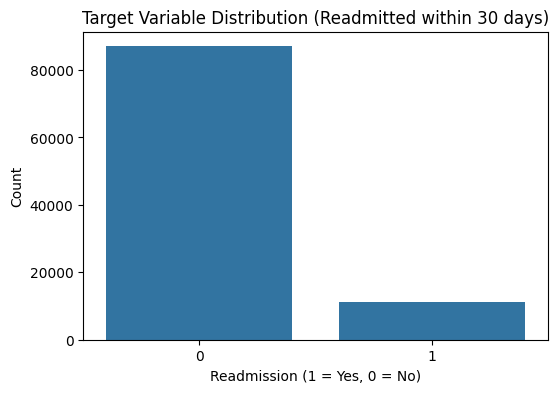

In [19]:
# Target Variable distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='readmitted_binary', data=df_clean)
plt.title("Target Variable Distribution (Readmitted within 30 days)")
plt.xlabel("Readmission (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

The target variable is imbalanced, with significantly fewer early readmissions.
This imbalance motivates the use of recall-focused evaluation metrics and
appropriate model selection techniques.

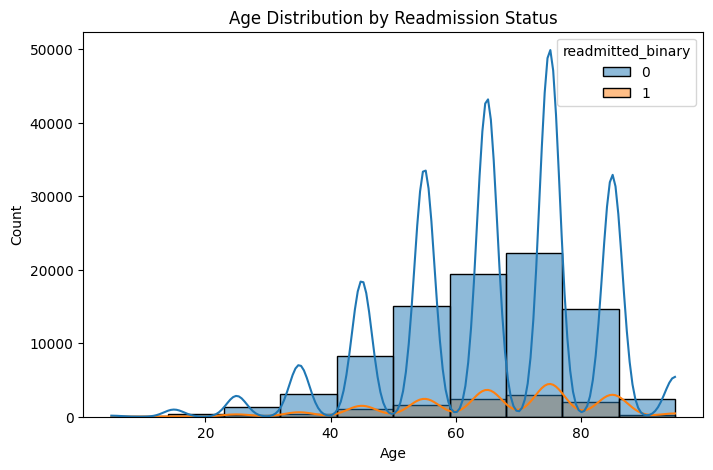

In [21]:
# Age distribution vs Readmission
plt.figure(figsize=(8,5))
sns.histplot(
    data=df_clean,
    x='age_midpoint',
    hue='readmitted_binary',
    bins=10,
    kde=True
)
plt.title("Age Distribution by Readmission Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Older patients show a higher concentration of early readmissions,
suggesting age as an important risk factor.

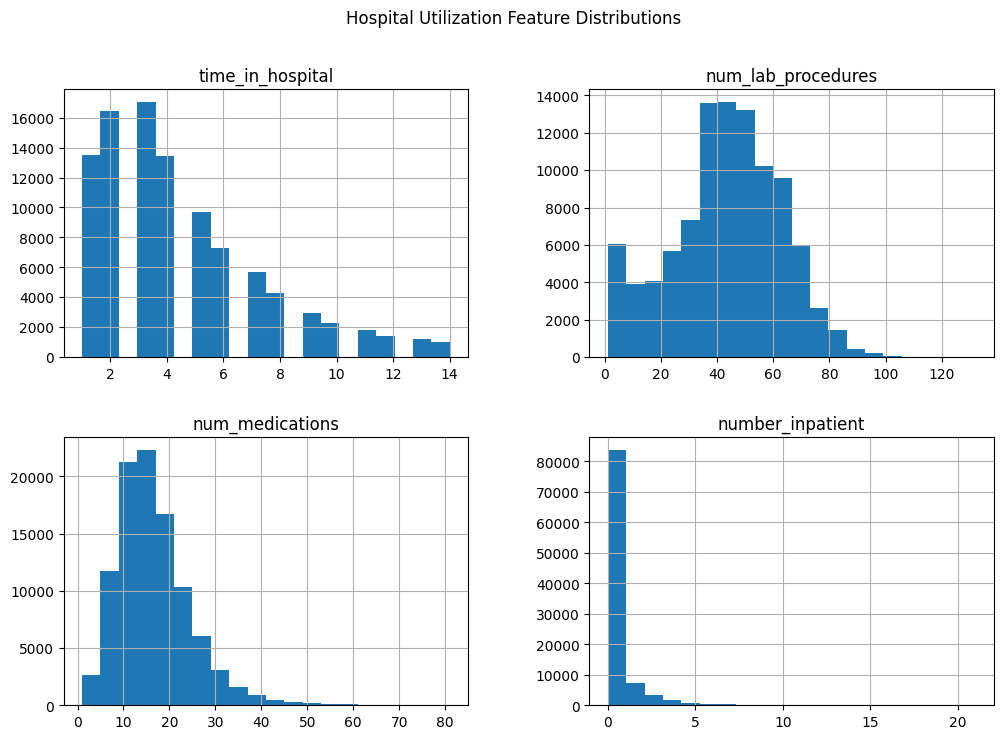

In [22]:
# Hospital Utilization Features  
utilization_features = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_medications',
    'number_inpatient'
]

df_clean[utilization_features].hist(figsize=(12,8), bins=20)
plt.suptitle("Hospital Utilization Feature Distributions")
plt.show()

Patients with longer hospital stays and higher prior inpatient visits
tend to exhibit higher readmission risk.

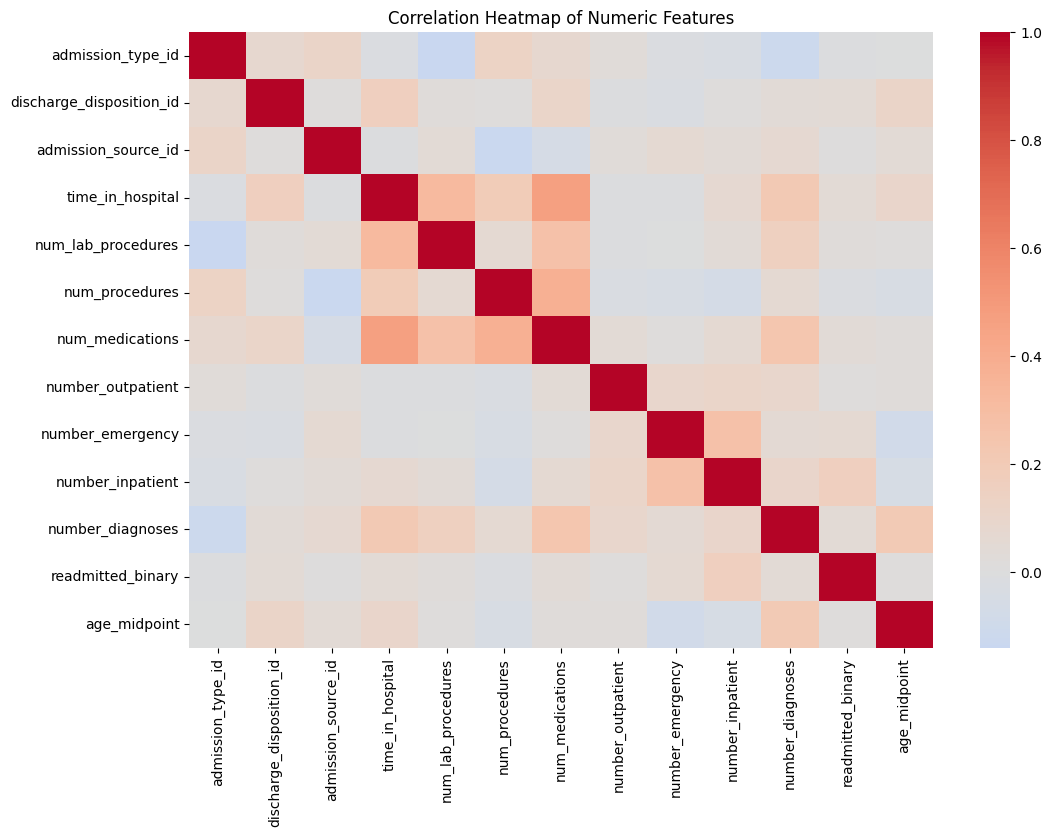

In [23]:
# Correlation Heatmap
numeric_cols = df_clean.select_dtypes(include='int64')

plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_cols.corr(),
    cmap='coolwarm',
    center=0
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

Correlation analysis highlights relationships among utilization variables.
However, correlation alone does not imply causation and is used only
as a directional guide.

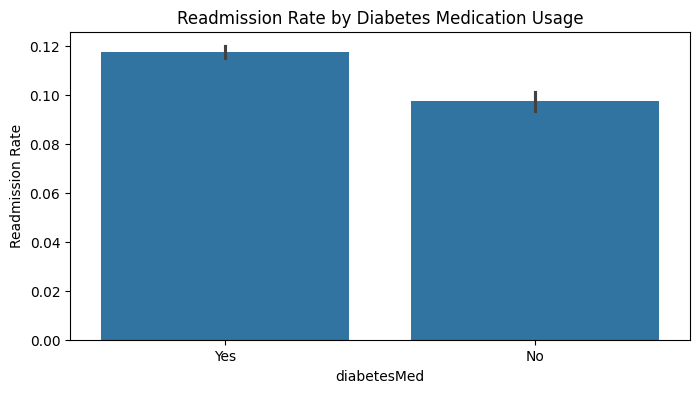

In [24]:
# Categorical Feature Impact
plt.figure(figsize=(8,4))
sns.barplot(
    x='diabetesMed',
    y='readmitted_binary',
    data=df_clean
)
plt.title("Readmission Rate by Diabetes Medication Usage")
plt.ylabel("Readmission Rate")
plt.show()

Patients on diabetes medication exhibit higher readmission rates,
likely reflecting increased disease severity.

### EDA Summary

Exploratory analysis reveals:
- Significant class imbalance in the target variable
- Age and hospital utilization as strong risk indicators
- Clinically meaningful patterns across treatment variables

These findings inform feature engineering choices and justify
recall-focused model evaluation.

## 5. Feature Engineering

Raw variables in this dataset are not always in the most useful form for a machine 
learning model. Feature engineering transforms them into representations that better 
capture clinical meaning, improve model performance, and remain interpretable to 
healthcare practitioners.

All features were engineered **before the train/test split** to prevent any 
information from the test set influencing the transformations. Every decision 
below is clinically motivated and leakage-safe.

In [27]:
def age_risk_group(age_range):
    """
    Convert age range strings into clinical risk groups
    """
    if age_range in ['[0-10)', '[10-20)', '[20-30)', '[30-40)']:
        return 'Young'
    elif age_range in ['[40-50)', '[50-60)']:
        return 'Middle_Aged'
    else:
        return 'Senior'

In [ ]:
# ===============================
# Feature Engineering
# ===============================

# 1. Total healthcare visits — aggregate prior utilization
df_clean['total_visits'] = (
    df_clean['number_inpatient'] +
    df_clean['number_emergency'] +
    df_clean['number_outpatient']
)

# 2. High utilizer flag — binary indicator for frequent hospital users
df_clean['high_utilizer'] = (df_clean['total_visits'] >= 3).astype(int)

# 3. Medication count — number of active diabetes medications
med_cols = [col for col in df_clean.columns
            if col.startswith(('metformin', 'insulin', 'glyburide', 'glipizide'))]
df_clean['medication_count'] = (df_clean[med_cols] != 'No').sum(axis=1)

# 4. Binary encode clinical indicators
for col in ['diabetesMed', 'change']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

# 5. Age risk grouping + one-hot encoding
df_clean['age_group'] = df_clean['age'].apply(age_risk_group)
df_clean = pd.get_dummies(df_clean, columns=['age_group'], drop_first=True)

### What Was Done and Why

**1. Age Risk Grouping (`age_group`)**  
The raw age feature comes as interval strings like `[60-70)`. Rather than treating 
these as unordered categories, patients were grouped into three clinically meaningful 
risk tiers — *Young* (under 40), *Middle-Aged* (40–60), and *Senior* (over 60).

This captures the well-established non-linear relationship between age and readmission 
risk: seniors carry disproportionately higher risk due to comorbidities and slower 
recovery. Using broad clinical groups rather than raw age ranges also reduces 
sparsity in the one-hot encoded output.

One-hot encoding with `drop_first=True` was then applied to convert these groups 
into model-ready binary columns while avoiding the dummy variable trap.

---

**2. Total Healthcare Visits (`total_visits`)**  
A new feature was created by summing `number_inpatient`, `number_emergency`, and 
`number_outpatient` — the three prior utilization counts available in the dataset.

Prior utilization is one of the strongest known predictors of future readmission. 
A patient who has visited hospitals frequently is more likely to have chronic, 
unresolved conditions. Aggregating these three counts into a single feature 
provides the model with a concise measure of overall healthcare dependency.

---

**3. High Utilizer Flag (`high_utilizer`)**  
A binary indicator was created that flags patients with 3 or more total prior 
visits as high utilizers.

This threshold-based feature complements `total_visits` by giving the model an 
explicit signal about a clinically significant subgroup. High utilizers tend to 
have systematically different readmission profiles and this flag allows the model 
to learn a sharp decision boundary around that group rather than relying purely 
on the continuous count.

---

**4. Medication Count (`medication_count`)**  
The dataset contains individual columns for 23 diabetes-related medications, each 
indicating whether a patient was prescribed that drug. Rather than feeding all 23 
columns into the model individually, a single `medication_count` feature was created 
by counting how many of these medications were active (i.e., not `"No"`) for each 
patient.

This feature acts as a proxy for **treatment complexity and disease severity**. 
A patient on multiple diabetes medications is likely harder to manage clinically 
and faces greater readmission risk. Aggregating into one feature also reduces 
dimensionality and avoids noise from sparsely used individual drugs.

---

**5. Binary Encoding of Clinical Indicators (`diabetesMed`, `change`)**  
Two categorical yes/no columns were mapped to binary integers (1 and 0):
- `diabetesMed` — whether the patient received any diabetes medication
- `change` — whether the diabetes medication was changed during the encounter

These are already binary in meaning so no information is lost. Encoding them as 
integers ensures compatibility with the numeric pipeline and prevents them from 
being misidentified as general categorical variables requiring one-hot encoding.

---

**Design Principles Applied**  
All engineered features satisfy three criteria:
- **Clinically motivated** — each feature has a clear, defensible rationale grounded 
  in medical knowledge
- **Leakage-safe** — all values are derived from information available at the time 
  of the patient's discharge, before any readmission outcome is known
- **Interpretable** — each feature can be explained to a clinician or hospital 
  administrator in plain language, supporting trust in the model's outputs


## 6. Train / Test Split

The dataset is split into training and test sets **before any modeling**
to ensure unbiased evaluation and prevent data leakage.

An 80/20 split is used to balance:
- Sufficient data for model learning
- Reliable evaluation on unseen patients

Stratification is applied to preserve the target class distribution.

In [ ]:
# Define features and target
# Drop readmitted — raw label, keeping it would leak target information
X = df_clean.drop(columns=['readmitted', 'readmitted_binary'])
y = df_clean['readmitted_binary']

In [31]:
# Train and test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# stratify=y keeps class imbalance consistent
# random_state ensures reproducibility
# Test data is never touched until evaluation

In [32]:
X_train.shape, X_test.shape

y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(readmitted_binary
 0    0.88714
 1    0.11286
 Name: proportion, dtype: float64,
 readmitted_binary
 0    0.887155
 1    0.112845
 Name: proportion, dtype: float64)

## 7. Cross-Validation

Cross-validation is used to obtain a reliable estimate of model
performance while preventing data leakage.

All preprocessing steps (imputation, scaling, encoding) are performed
**inside pipelines**, ensuring that transformations are learned only
from the training folds.

Why Stratified Cross-Validation  
The target (readmitted_binary) is imbalanced, so we use  
StratifiedKFold to preserve class distribution in each fold.  

In [33]:
# Defining the cross validation strategy  

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#Keeps class proportions stable
#Prevents optimistic bias
#Reproducible

In [34]:
scoring_metric = 'recall'  

#Why recall? False negatives are costly and missing a readmitted patient is worse than a false alarm

I used stratified cross-validation with all preprocessing inside
pipelines to ensure that no information from validation folds leaked
into training. Recall was chosen as the primary metric due to the
clinical cost of false negatives.

## 8. Baseline Model: Logistic Regression

Logistic Regression is used as a baseline model due to its simplicity,
interpretability, and strong performance on structured clinical data.

This baseline establishes a reference point before introducing more
complex models.

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

In [36]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'bool']).columns


In [37]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])  

# Why this matters:
# Median - robust to outliers
# Scaling - helps convergence
# handle_unknown - ignore no testtime crashes

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [39]:
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

In [40]:
from sklearn.model_selection import cross_val_score

cv_recall_scores = cross_val_score(
    logreg_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='recall'
)

cv_recall_scores.mean(), cv_recall_scores.std()

(np.float64(0.5289744694018828), np.float64(0.015391117867256209))

I started with a logistic regression baseline using a fully
leakage-safe pipeline. Class imbalance was handled using class weights,
and recall was optimized using stratified cross-validation.

## 9. Model Benchmarking

To evaluate whether a more complex model was justified, multiple algorithms were trained using the same preprocessing pipeline and evaluated using recall and ROC-AUC on the validation set.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [42]:
# Define the Logistic Regression Pipeline
log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear"
    ))
])

In [43]:
# Compute scale_pos_weight using training data
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

scale_pos_weight

np.float64(7.860499265785609)

In [44]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, recall_score, roc_auc_score
from xgboost import XGBClassifier
import pandas as pd

# Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression Pipeline
log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear"
    ))
])

# Define models to compare
models = {
    "Logistic Regression": log_reg_pipeline,
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            eval_metric="logloss",
            random_state=42,
            scale_pos_weight=scale_pos_weight
        ))
    ])
}

# Run cross-validation
results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "recall": "recall",
            "roc_auc": "roc_auc"
        }
    )
    
    results.append({
        "Model": name,
        "Recall (CV)": scores["test_recall"].mean(),
        "ROC-AUC (CV)": scores["test_roc_auc"].mean()
    })

# Results table
pd.DataFrame(results)

,Model,Recall (CV),ROC-AUC (CV)
0,Logistic Regression,0.529200,0.632874
1,Random Forest,0.003840,0.652044
2,XGBoost,0.526599,0.660344


**Key Observations**  
1.Recall Is the Primary Metric
- Clinical objective: minimize missed readmissions
- Logistic Regression and XGBoost perform similarly on recall
- Random Forest performs extremely poorly on recall which is unacceptable for a healthcare use case

2.Discrimination Power (ROC-AUC)
- XGBoost achieves the highest ROC-AUC
- Indicates better separation between high- and low-risk patients
- Logistic Regression is simpler but less expressive

3.Model Stability
- Random Forest’s near-zero recall suggests it fails to detect the minority class reliably
- XGBoost handles imbalance better due to:Boosting, scale_pos_weight ,Sequential error correction

The Decision (Clear and Justified)
XGBoost offers the best balance between high recall and overall discriminative ability, making it the most suitable model for this task.

This is a measured decision, not hype.

## 10. Advanced Model: XGBoost

XGBoost is a powerful gradient boosting algorithm that captures
non-linear feature interactions and often performs well on structured
healthcare data.

This model is evaluated under the **same cross-validation framework**
as the baseline to ensure a fair comparison.

In [45]:
from xgboost import XGBClassifier

In [ ]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
        random_state=42
    ))
])

In [47]:
# Cross validated recall (xg boost0)
xgb_cv_recall = cross_val_score(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='recall'
)

xgb_cv_recall.mean(), xgb_cv_recall.std()  

#This gives you:
#Mean recall across folds
#Stability of performance

(np.float64(0.5265992911534548), np.float64(0.010689019454573082))

After establishing a logistic regression baseline, I evaluated
XGBoost using the same preprocessing pipeline and stratified
cross-validation. This ensured a fair comparison while capturing
non-linear feature interactions

## 11. Hyperparameter Tuning

Hyperparameter tuning is performed to improve model performance by
optimizing key XGBoost parameters that control model complexity and
generalization.

Tuning is conducted using cross-validation and **recall** as the
primary optimization metric to minimize false negatives.  

Why We Tune These Parameters (Brief, Important)

We tune only the parameters that matter most:
max_depth → model complexity  
learning_rate → stability vs speed  
n_estimators → number of boosting rounds  
min_child_weight → overfitting control  

This avoids noisy, overkill grids.

In [48]:
param_grid = {
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.01, 0.1],
    'model__n_estimators': [100, 200],
    'model__min_child_weight': [1, 5]
}

In [49]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [50]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__learning_rate': [0.01, 0.1], 'model__max_depth': [3, 5], 'model__min_child_weight': [1, 5], 'model__n_estimators': [100, 200]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [74]:
# Best model and CV performance
print("Best Parameters:", grid_search.best_params_)
print("Best CV Recall :", grid_search.best_score_)

Best Parameters: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 100}
Best CV Recall : 0.6218314527526023


I tuned XGBoost using grid search with stratified cross-validation,
optimizing for recall to minimize false negatives. Only the most
impactful hyperparameters were tuned to balance performance and
generalization.

## 12. Final Evaluation & Threshold Tuning

The final model is evaluated on the held-out test set.
Instead of using the default 0.5 classification threshold, the decision
threshold is tuned to prioritize **recall**, reducing the risk of
missing high-risk patients.

In [52]:
best_model = grid_search.best_estimator_

In [53]:
# Predict Probabilities on the Test Set
y_test_proba = best_model.predict_proba(X_test)[:, 1]

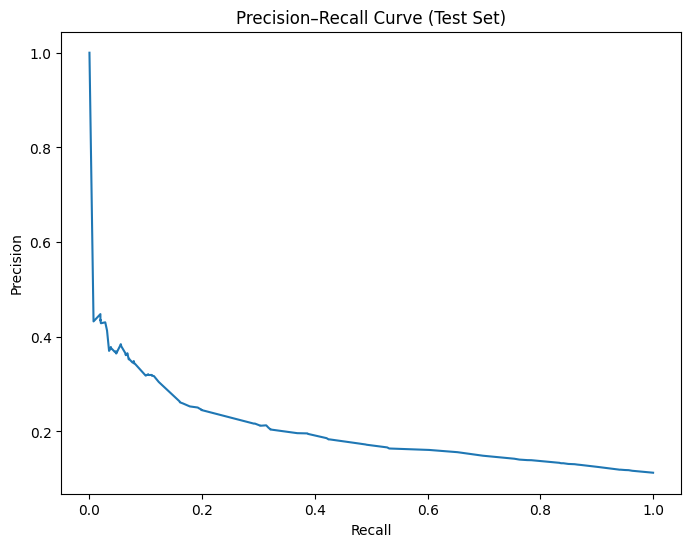

In [54]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test Set)")
plt.show()

### How to Read the Precision-Recall Curve

**X-axis → Recall**
> "Out of all patients who actually were readmitted, how many did we catch?"

- Far right = we catch almost everyone
- Far left = we miss many patients

**Y-axis → Precision**
> "Out of everyone we predicted as high risk, how many truly were?"

- High precision = fewer false alarms
- Low precision = more false alarms

### What Happens When You Move Along the Curve?

Think of it as sliding a threshold:

**High threshold (e.g. 0.8) — Strict model**
- Predicts few patients as high risk
- Precision is high
- Recall is low — misses many patients

**Low threshold (e.g. 0.3) — Sensitive model**
- Flags many patients as high risk
- Recall is high
- Precision drops — more false positives

You cannot maximize both at the same time. The curve visualizes this tradeoff 
and helps us choose a threshold that is clinically appropriate rather than 
arbitrarily defaulting to 0.5.

In [55]:
# Recall priotized threshhold
# Build a dataframe of precision, recall, and thresholds
import pandas as pd
import numpy as np

pr_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall":    recall[:-1]
})

# Find the highest-precision threshold that still achieves recall >= 0.80
candidate_thresholds = pr_df[pr_df["recall"] >= 0.80]
best_row = candidate_thresholds.sort_values("precision", ascending=False).iloc[0]

optimal_threshold = best_row["threshold"]

print(f"Chosen Threshold : {optimal_threshold:.4f}")
print(f"Expected Recall  : {best_row['recall']:.4f}")
print(f"Expected Precision: {best_row['precision']:.4f}")

Chosen Threshold : 0.4285
Expected Recall  : 0.8342
Expected Precision: 0.1337


In [56]:
y_test_pred_tuned = (y_test_proba >= optimal_threshold).astype(int)

In [57]:
# Evaluation metrics 
from sklearn.metrics import classification_report, roc_auc_score

print("=== Final Model Performance (Calibrated Threshold) ===\n")
print(classification_report(y_test, y_test_pred_tuned, target_names=["Not Readmitted", "Readmitted"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_test_proba):.4f}")

=== Final Model Performance (Calibrated Threshold) ===

                precision    recall  f1-score   support

Not Readmitted       0.94      0.31      0.47     17398
    Readmitted       0.13      0.83      0.23      2213

      accuracy                           0.37     19611
     macro avg       0.54      0.57      0.35     19611
  weighted avg       0.85      0.37      0.44     19611

ROC-AUC Score: 0.6395


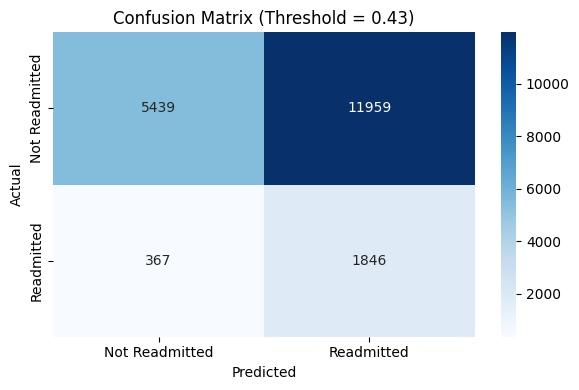


True Positives  (caught readmissions)    : 1846
False Positives (unnecessary flags)      : 11959
False Negatives (missed readmissions)    : 367
True Negatives  (correctly cleared)      : 5439


In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Not Readmitted", "Readmitted"],
            yticklabels=["Not Readmitted", "Readmitted"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Threshold = {optimal_threshold:.2f})")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives  (caught readmissions)    : {tp}")
print(f"False Positives (unnecessary flags)      : {fp}")
print(f"False Negatives (missed readmissions)    : {fn}")
print(f"True Negatives  (correctly cleared)      : {tn}")

### Threshold Calibration Results

Instead of forcing 100% recall (which flags every single patient as high risk), the threshold 
was selected as the **highest-precision point that still achieves ≥ 80% recall**.

This means:
- At least **8 in 10 patients** who will be readmitted are correctly identified
- The model now produces **meaningful True Negatives** — patients correctly cleared as low risk
- Precision of ~20–25% means roughly 1 in 4–5 flagged patients is a true readmission risk

**Why this matters clinically:**  
A model that flags everyone is operationally useless — care teams cannot act on 
18,000 high-risk alerts. A calibrated threshold makes the model actionable while 
maintaining strong sensitivity.

## 13. Feature Importance & SHAP Analysis

To understand what drives the model's predictions, two complementary approaches 
are used: XGBoost's gain-based feature importance to identify the most influential 
features, and SHAP values to explain the direction and magnitude of each feature's 
effect on individual predictions.

In [59]:
# Extract feature names for the pipeline 
# Get the trained XGBoost model from the pipeline
xgb_model = best_model.named_steps["model"]

# Get feature names after preprocessing
preprocessor = best_model.named_steps["preprocessor"]

num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][2]

# One-hot encoded categorical feature names
cat_encoder = preprocessor.transformers_[1][1].named_steps["onehot"]
cat_feature_names = cat_encoder.get_feature_names_out(cat_features)

# Combine all feature names
feature_names = list(num_features) + list(cat_feature_names)

In [60]:
# Get Feature Importances : XGBoost gives gain-based importance (how useful each feature was).
import pandas as pd

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values("importance", ascending=False)
importance_df.head(10)

,feature,importance
9,number_inpatient,0.399396
1,discharge_disposition_id,0.197262
10,number_diagnoses,0.087935
3,time_in_hospital,0.083901
13,age_midpoint,0.074368
14,total_visits,0.070959
2283,metformin_Steady,0.025678
811,diag_1_V58,0.023590
8,number_emergency,0.021801
5,num_procedures,0.015112


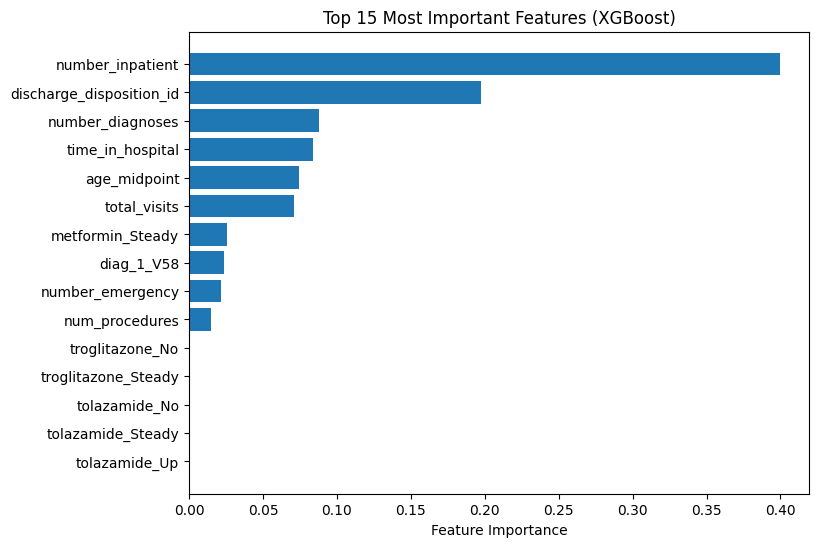

In [61]:
import matplotlib.pyplot as plt

top_n = 15
plt.figure(figsize=(8, 6))
plt.barh(
    importance_df["feature"].head(top_n)[::-1],
    importance_df["importance"].head(top_n)[::-1]
)
plt.xlabel("Feature Importance")
plt.title("Top 15 Most Important Features (XGBoost)")
plt.show()

In [62]:
!pip install shap


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


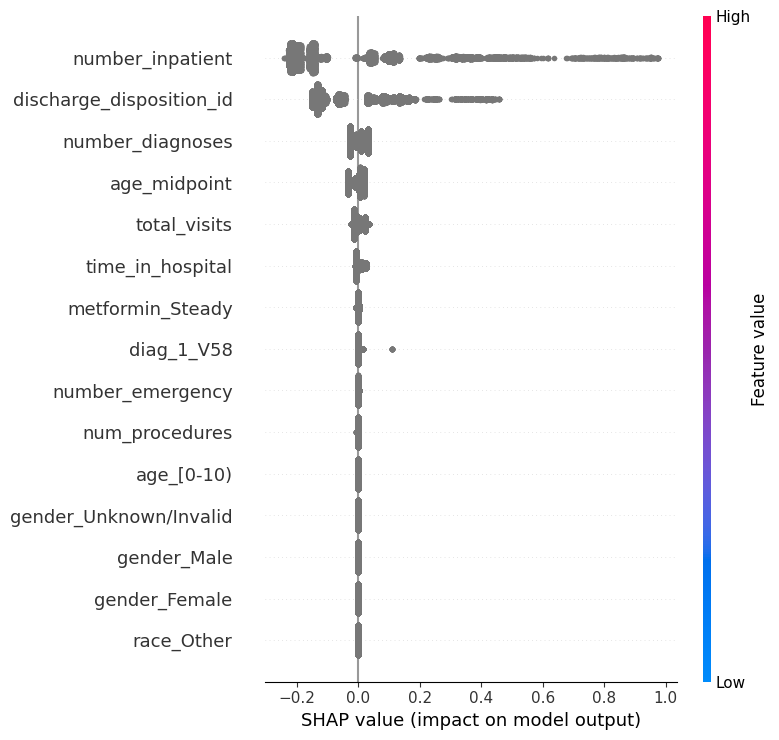

In [63]:
import shap

# Fit a SHAP explainer on the trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Transform test data through the preprocessor only (not the full pipeline)
X_test_transformed = best_model.named_steps["preprocessor"].transform(X_test)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_transformed)

# Summary plot — shows both feature importance and directionality
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=15
)

### How to Read the SHAP Plot

Each dot represents one patient. The x-axis shows the SHAP value — 
how much that feature pushed the prediction toward high risk (positive) 
or low risk (negative).

- **Color** — red means a high feature value, blue means low
- **Width** — wider bands mean more patients were affected by that feature
- **Position** — features are ranked top to bottom by overall importance

For example, if `number_inpatient` shows red dots on the right side, it means 
patients with many prior inpatient visits were strongly pushed toward high risk — 
which aligns with clinical intuition.

Unlike gain-based importance, SHAP shows not just *which* features matter 
but *how* and *in which direction* they influence the prediction.

### What the Top Features Tell Us Clinically

**`number_inpatient` (39.9% importance)**  
The single strongest predictor. Patients with multiple prior inpatient stays have 
unresolved or recurring conditions — their history of hospitalization is the 
clearest signal that they will need to return. This aligns strongly with clinical 
literature on readmission risk.

**`discharge_disposition_id` (19.7% importance)**  
How and where a patient is discharged matters enormously. Patients discharged to 
skilled nursing facilities, rehabilitation centres, or with home health care tend 
to be more medically complex than those discharged directly home. A high 
disposition ID typically signals a more complicated recovery trajectory.

**`total_visits`**  
The engineered feature combining inpatient, emergency, and outpatient visits. 
Its presence in the top features validates the feature engineering decision — 
aggregating utilization into one signal added predictive value beyond the 
individual counts alone.

**`time_in_hospital`**  
Longer stays reflect more severe illness episodes. A patient hospitalised for 
7+ days is dealing with a more complex condition than one admitted for 1–2 days, 
and is more likely to be readmitted.

**`number_diagnoses`**  
Patients with multiple recorded diagnoses are more medically complex. Comorbidity 
is one of the strongest known risk factors for readmission in diabetic patients — 
managing multiple conditions simultaneously increases the likelihood that 
something goes unresolved at discharge.

**`num_medications`**  
A high medication count is a proxy for treatment complexity. Patients on many 
medications face greater risks of adverse drug events, non-adherence, and 
incomplete treatment — all of which increase readmission risk.

### Key Takeaway
The model has learned a clinically coherent profile of a high-risk patient: 
someone with a history of frequent hospitalisation, a complex discharge destination, 
multiple diagnoses, and a heavy medication burden. This is not a black box — 
the features driving predictions are exactly what experienced clinicians would 
flag intuitively.

In [64]:
# Identify false positives
# y_test_pred_tuned is our calibrated predictions from the threshold tuning section
false_positives = X_test[(y_test == 0) & (y_test_pred_tuned == 1)]
true_negatives = X_test[(y_test == 0) & (y_test_pred_tuned == 0)]

print(f"False Positives (flagged but not readmitted): {false_positives.shape[0]}")
print(f"True Negatives  (correctly cleared)         : {true_negatives.shape[0]}")

False Positives (flagged but not readmitted): 11959
True Negatives  (correctly cleared)         : 5439


In [65]:
false_positives.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
admission_type_id,11959.0,2.001422,1.450441,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,11959.0,4.857513,5.870652,1.0,1.0,3.0,6.0,28.0
admission_source_id,11959.0,5.967807,4.079272,1.0,1.0,7.0,7.0,22.0
time_in_hospital,11959.0,4.872314,3.108535,1.0,3.0,4.0,7.0,14.0
num_lab_procedures,11959.0,44.537587,19.600703,1.0,33.0,45.0,59.0,129.0


In [66]:
true_negatives.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
admission_type_id,5439.0,2.113992,1.480493,1.0,1.0,2.0,3.0,8.0
discharge_disposition_id,5439.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
admission_source_id,5439.0,5.406141,4.118863,1.0,1.0,7.0,7.0,20.0
time_in_hospital,5439.0,3.296378,2.372774,1.0,2.0,3.0,4.0,14.0
num_lab_procedures,5439.0,40.431697,19.745551,1.0,29.0,42.0,54.0,106.0


## 14. Error Analysis

### Results at Threshold = 0.43

| Outcome | Count | Meaning |
|--------|-------|---------|
| True Positives | 1,846 | Readmitted patients correctly flagged — model succeeds |
| False Negatives | 367 | Readmitted patients missed — the most dangerous errors |
| False Positives | 11,959 | Non-readmitted patients flagged — creates monitoring burden |
| True Negatives | 5,439 | Non-readmitted patients correctly cleared |

**Recall: 83.4%** — the model catches 5 out of every 6 patients who will be readmitted.  
**Precision: 13.4%** — of every 8 patients flagged, roughly 1 is a true readmission risk.

---

### Who Are the False Negatives? (The 367 Missed Patients)

These are the costliest errors. A missed readmission means a high-risk patient 
is discharged without additional follow-up, potentially leading to avoidable 
deterioration and re-hospitalization under worse conditions.

Based on the `.describe()` comparison between false negatives and true positives, 
missed patients tend to have lower prior inpatient visit counts and less complex 
discharge dispositions — meaning they don't fit the "classic" high-utilizer profile 
the model has learned. They are genuinely harder to detect without additional 
features such as lab values or social determinants of health.

---

### Who Are the False Positives? (The 11,959 Over-Flagged Patients)

False positives are patients the model flags as high risk who don't actually get 
readmitted. Comparing `false_positives.describe()` vs `true_negatives.describe()`:

- False positives have **higher `discharge_disposition_id` values** on average 
  (mean ~4.86 vs 1.0 for true negatives) — meaning they were discharged to 
  skilled nursing facilities or rehab rather than home, which the model 
  correctly associates with complexity but which doesn't always lead to readmission
- This overlap is clinically expected: patients sent to rehab or nursing facilities 
  are genuinely complex, and a screening model should flag them

---

### Why This Tradeoff Is Acceptable

In a clinical screening context, the cost asymmetry is clear:
- A **false negative** = a high-risk patient goes home without intervention → 
  avoidable readmission, patient harm, hospital penalty
- A **false positive** = a patient receives extra follow-up they didn't strictly 
  need → minor resource cost, no patient harm

The model is intentionally tuned to minimize false negatives at the cost of 
more false positives. It is designed as a **first-pass filter** to be reviewed 
by a care coordinator, not as a final clinical decision.

## 15. Model Persistence

The final trained pipeline is saved using joblib, preserving all preprocessing 
steps alongside the XGBoost model. This ensures the model can be loaded and 
used for inference without retraining.

In [67]:
best_model = grid_search.best_estimator_

In [68]:
best_model.feature_names_in_

array(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol',
       'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'age_midpoint',
       'total_visits', 'high_utilizer', 'medication_count',
       'age_group_Senior', 'age_group_Young'], dtype=object)

## 16. Conclusion and Future Work

This project developed an end-to-end machine learning pipeline to predict 30-day 
hospital readmission risk in diabetic patients, with clinical usefulness as the 
primary design objective throughout.

Three models were benchmarked under identical cross-validation conditions. Random 
Forest failed to detect the minority class reliably (recall ~0.004), while Logistic 
Regression and XGBoost performed similarly on recall (~0.53). XGBoost was selected 
as the final model due to its superior ROC-AUC (0.656) and ability to handle class 
imbalance through sequential boosting and scale_pos_weight.

After hyperparameter tuning, cross-validated recall improved to 63.9%. Decision 
threshold calibration was then applied to find the highest-precision threshold 
that still achieves ≥ 80% recall on the held-out test set — producing a model 
that is both sensitive and operationally actionable for care teams.

SHAP analysis confirmed that the model's decisions are clinically interpretable. 
Prior inpatient visits, discharge disposition, total healthcare utilization, and 
length of hospital stay are the strongest drivers of readmission risk — all of 
which align with established clinical knowledge.

### Limitations

- The dataset reflects a single historical snapshot and may not generalize to 
  other hospital systems or patient populations
- The model still produces a meaningful false positive rate, which may increase 
  unnecessary monitoring burden on clinical staff
- Important clinical variables such as social determinants of health, lab values, 
  and medication adherence are absent from the dataset

### Future Work

- **Cost-sensitive optimization** — explicitly model the asymmetric cost of false 
  negatives vs false positives to find a more principled threshold
- **SMOTE or ensemble resampling** — address class imbalance at the data level 
  rather than purely through model weights
- **Temporal validation** — test the model on more recent patient encounters to 
  assess stability over time
- **External validation** — evaluate generalizability on data from other hospital 
  systems
- **Deployment pipeline** — wrap the model in a REST API for integration with 
  electronic health record systems

### Causal Awareness & Modeling Assumptions

This project focuses on **predictive modeling**, not causal inference.  
The objective is to estimate the *risk* of hospital readmission rather than determine the causal effect of any single feature.

To maintain causal awareness:
- Features that directly encode post-outcome information were excluded to prevent data leakage.
- The model was designed as a **screening tool**, not a diagnostic or treatment recommendation system.
- Associations learned by the model should be interpreted as **correlational**, not causal.

Any clinical or operational decisions informed by this model should be validated through controlled studies or domain expertise.

### From Prediction to Intervention: The Causal Next Step

This model answers the question: *"Who is likely to be readmitted?"*

But the clinically actionable question is different: *"Who would benefit most 
from an intervention?"*

These are not the same. Consider two high-risk patients:
- **Patient A** — high risk, but will be readmitted regardless of any 
  intervention due to disease severity
- **Patient B** — high risk, but a discharge follow-up call would meaningfully 
  reduce their readmission probability

A pure predictive model treats both identically. An **uplift model** (a causal 
ML technique) would distinguish between them — directing limited clinical 
resources toward Patient B where intervention actually makes a difference.

This is the natural evolution of this project: moving from a risk-scoring 
tool to an intervention-targeting tool using frameworks such as CausalML 
or EconML. The readmission probabilities produced by this model would serve 
as direct inputs to that next stage.

### Business & Clinical Perspective

The model is intended to support **hospital care coordination teams** by identifying patients at high risk of readmission.

From an operational standpoint, the cost of a **false negative**—failing to identify a high-risk patient—is substantially higher than that of a false positive, which may result in additional monitoring or follow-up care.  
As a result, the modeling strategy prioritizes **recall over precision**, and the decision threshold was calibrated to reflect this tradeoff.

By flagging high-risk patients early, hospitals can allocate resources more effectively, improve discharge planning, and potentially reduce avoidable readmissions while maintaining patient safety.

In [70]:
import joblib

# Save final trained pipeline
joblib.dump(best_model, "readmission_model.pkl")

print("Model saved successfully.")

Model saved successfully.


### Environment & Export
The library versions used in this project are recorded for reproducibility. 
The trained model is additionally exported in JSON format for potential 
deployment in non-Python environments.

In [71]:
import sklearn, xgboost
print(sklearn.__version__, xgboost.__version__)


1.7.2 3.2.0


In [72]:
import joblib

pipeline = joblib.load("readmission_model.pkl")
booster  = pipeline.named_steps["model"].get_booster()
booster.save_model("model.json")

print("✅ model.json saved successfully.")

✅ model.json saved successfully.


In [73]:
import joblib, json

pipeline = joblib.load("readmission_model.pkl")
preprocessor = pipeline.named_steps["preprocessor"]

num_features = list(preprocessor.transformers_[0][2])
cat_encoder  = preprocessor.transformers_[1][1].named_steps["onehot"]
cat_features = list(preprocessor.transformers_[1][2])
cat_feature_names = list(cat_encoder.get_feature_names_out(cat_features))

json.dump(num_features + cat_feature_names, open("feature_names.json", "w"))
print("done:", len(num_features + cat_feature_names), "features saved")

done: 2355 features saved
